In [2]:
from pathlib import Path
import sys
from collections import Counter
import random
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import numpy as np
import hashlib
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
anime_data_path = PROJECT_ROOT / "data" / "raw_data" / "anime"
print("Anime Dataset Exists:", anime_data_path.exists())
print("Contents (first 10):", list(anime_data_path.iterdir())[:10])
real_data_path =PROJECT_ROOT / "data" / "raw_data" / "real"
print("Real dataset Exists:", real_data_path.exists())
print("Contents (first 10):", list(real_data_path.iterdir())[:10])

Anime Dataset Exists: True
Contents (first 10): [WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/0_2000.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10000_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10001_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10002_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10003_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10004_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10005_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10006_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10007_2004.jpg'), WindowsPath('c:/Users/Dileep Kumar/Desktop/Face-Anime-AI/data/raw_data/anime/10008_2004.jpg')]
Real 

# Methods

In [3]:
def get_image_path(path):
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    images = [f for f in path.iterdir() if f.suffix.lower() in image_extensions]
    print(f"Found {len(images)} images")
    print(f"Total images: {len(images)}")
    return images

In [4]:
def get_corrupt_images(images):
    sizes = []              
    valid_images = []     
    corrupt_files = []

    for img_path in images:
        try:
            with Image.open(img_path) as img:
                img.verify()
            with Image.open(img_path) as img:
                sizes.append(img.size)   
            valid_images.append(img_path) 
        except (UnidentifiedImageError, OSError, Exception) as e:
            corrupt_files.append((img_path, str(e)))

    print(f"Valid images: {len(valid_images)}")
    print(f"Corrupt/unreadable images: {len(corrupt_files)}")

    if corrupt_files:
        print("\nCorrupt files found:")
        for path, err in corrupt_files[:20]:
            print(f"  {path.name} → {err}")

    size_counts = Counter(sizes)
    print("\nUnique sizes found:")
    for size, count in size_counts.most_common(10):
        print(f"{size}: {count} images")
    return valid_images,corrupt_files,size_counts

In [5]:
def show_random_images(valid_images):
    samples = random.sample(valid_images, min(5, len(valid_images)))

    fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [6]:
def channel_detection(valid_images):
    modes = []
    for img_path in valid_images:
        try:
            with Image.open(img_path) as img:
                modes.append(img.mode)
        except Exception:
            continue 

    mode_counts = Counter(modes)
    print("Color channel modes found:")
    for mode, count in mode_counts.most_common():
        print(f"{mode}: {count} images")
    return mode_counts

In [7]:
def compute_statistics(valid_images):
    sample_size = min(200, len(valid_images))
    sample_paths = random.sample(valid_images, sample_size)

    means, stds = [], []
    for img_path in sample_paths:
        try:
            with Image.open(img_path) as img:
                arr = np.array(img.convert("RGB")) / 255.0
                means.append(arr.mean(axis=(0, 1)))
                stds.append(arr.std(axis=(0, 1)))
        except Exception:
            continue

    means = np.array(means)
    stds = np.array(stds)

    print(f"Mean pixel value per channel (R,G,B): {means.mean(axis=0)}")
    print(f"Std pixel value per channel (R,G,B): {stds.mean(axis=0)}")
    return means,stds

In [8]:

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def duplicate_images(valid_images):
    hashes = {}
    duplicates = []

    for img_path in valid_images:
        h = file_hash(img_path)
        if h in hashes:
            duplicates.append((img_path, hashes[h]))
        else:
            hashes[h] = img_path

    print(f"Duplicate images found: {len(duplicates)}")
    for dup, original in duplicates[:20]:
        print(f"  {dup.name}  ==  {original.name}")
    return duplicates

In [9]:
def summary(images,valid_images,corrupt_files,duplicates,means,mode_counts,size_counts):
    print("=" * 50)
    print("DATASET SUMMARY")
    print("=" * 50)
    print(f"Total images found:      {len(images)}")
    print(f"Valid images:            {len(valid_images)}")
    print(f"Corrupt images:          {len(corrupt_files)}")
    print(f"Duplicate images:        {len(duplicates)}")
    print(f"Unique image sizes:      {len(size_counts)}")
    print(f"Most common size:        {size_counts.most_common(1)[0] if size_counts else 'N/A'}")
    print(f"Color modes present:     {dict(mode_counts)}")
    print(f"Mean pixel (R,G,B):      {means.mean(axis=0).round(3) if len(means) else 'N/A'}")
    print("=" * 50)

    print("\nRecommended next steps:")
    if corrupt_files:
        print(f"- Remove or fix {len(corrupt_files)} corrupt images before training")
    if duplicates:
        print(f"- Remove {len(duplicates)} duplicate images to avoid data leakage")
    if len(size_counts) > 1:
        print(f"- Images have {len(size_counts)} different sizes — add a resize step in your data pipeline")
    if len(mode_counts) > 1:
        print(f"- Mixed color modes detected — convert all to RGB with img.convert('RGB') during loading")

# Exploratory Data Analysis for Anime Data

Found 63565 images
Total images: 63565
Valid images: 63565
Corrupt/unreadable images: 0

Unique sizes found:
(92, 92): 1636 images
(96, 96): 1556 images
(94, 94): 1534 images
(95, 95): 1530 images
(90, 90): 1516 images
(98, 98): 1500 images
(91, 91): 1447 images
(99, 99): 1439 images
(93, 93): 1434 images
(97, 97): 1406 images


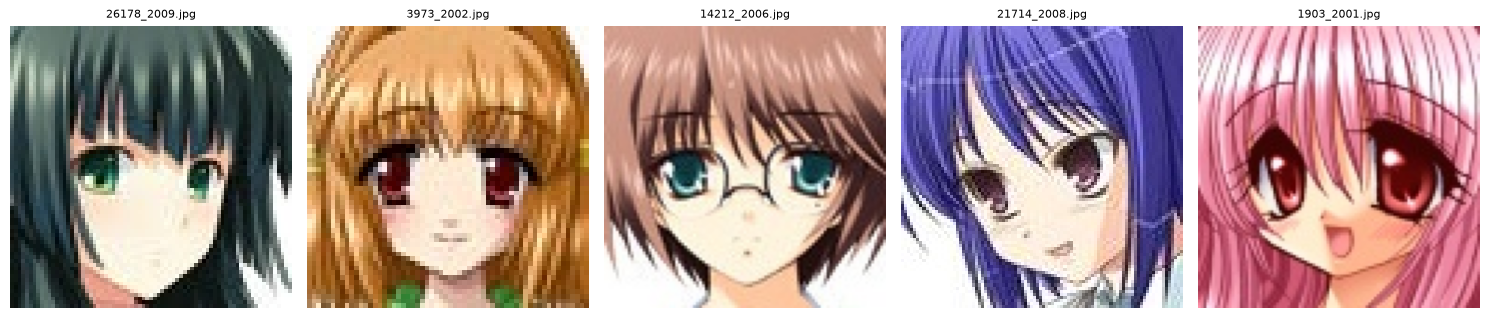

Color channel modes found:
RGB: 63565 images
Mean pixel value per channel (R,G,B): [0.69471085 0.59279019 0.56953632]
Std pixel value per channel (R,G,B): [0.24778131 0.26223746 0.2430937 ]
Duplicate images found: 22043
  10056_2004.jpg  ==  10047_2004.jpg
  1007_2000.jpg  ==  1006_2000.jpg
  10126_2004.jpg  ==  10068_2004.jpg
  10167_2004.jpg  ==  10073_2004.jpg
  10255_2004.jpg  ==  10150_2004.jpg
  10264_2004.jpg  ==  10259_2004.jpg
  10267_2004.jpg  ==  10133_2004.jpg
  10278_2004.jpg  ==  10139_2004.jpg
  10281_2004.jpg  ==  10131_2004.jpg
  10314_2004.jpg  ==  10216_2004.jpg
  10333_2004.jpg  ==  10268_2004.jpg
  10336_2004.jpg  ==  10054_2004.jpg
  10337_2004.jpg  ==  10122_2004.jpg
  10339_2004.jpg  ==  10280_2004.jpg
  10351_2004.jpg  ==  10064_2004.jpg
  10352_2004.jpg  ==  10261_2004.jpg
  10358_2004.jpg  ==  10357_2004.jpg
  10367_2004.jpg  ==  10041_2004.jpg
  10479_2005.jpg  ==  10466_2005.jpg
  10552_2005.jpg  ==  10469_2005.jpg
DATASET SUMMARY
Total images found:      6

In [10]:
anime_images=get_image_path(anime_data_path)
valid_anime_images,corrupt_anime_files,anime_size_count=get_corrupt_images(anime_images)
show_random_images(valid_anime_images)
anime_mode_count=channel_detection(valid_anime_images)
anime_means,anime_stds=compute_statistics(valid_anime_images)
duplicate_anime_images=duplicate_images(valid_anime_images)
summary(anime_images,valid_anime_images,corrupt_anime_files,duplicate_anime_images,anime_means,anime_mode_count,anime_size_count)


# Exploratory Data Analysis For Real_Data

Found 202599 images
Total images: 202599
Valid images: 202599
Corrupt/unreadable images: 0

Unique sizes found:
(178, 218): 202599 images


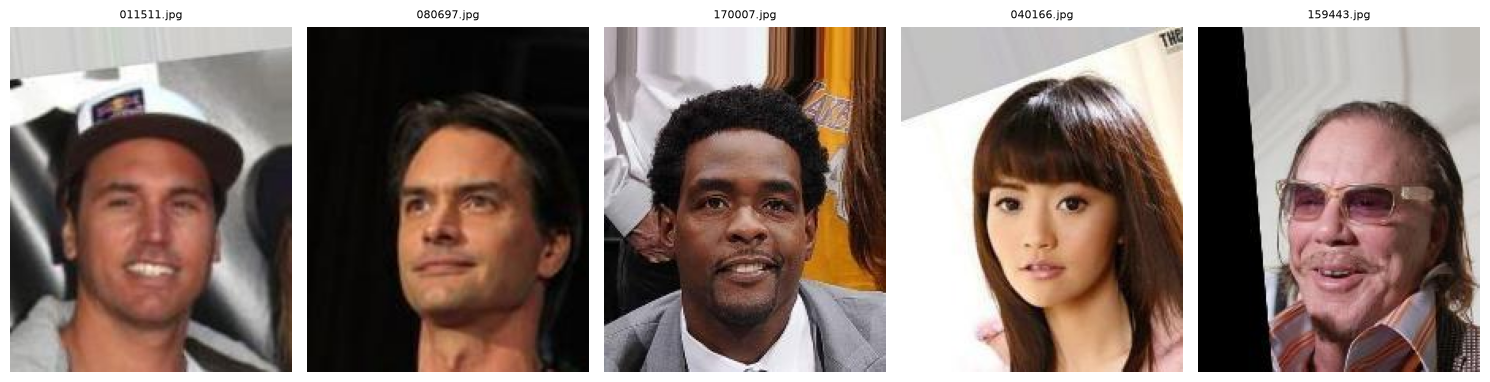

Color channel modes found:
RGB: 202599 images
Mean pixel value per channel (R,G,B): [0.50479481 0.41865964 0.37274431]
Std pixel value per channel (R,G,B): [0.26939518 0.24370447 0.23459893]
Duplicate images found: 131
  014364.jpg  ==  012589.jpg
  019471.jpg  ==  007227.jpg
  021423.jpg  ==  019673.jpg
  049003.jpg  ==  011318.jpg
  055807.jpg  ==  030146.jpg
  056985.jpg  ==  015484.jpg
  057990.jpg  ==  043513.jpg
  058721.jpg  ==  020782.jpg
  065708.jpg  ==  047447.jpg
  066034.jpg  ==  002538.jpg
  069351.jpg  ==  029535.jpg
  069531.jpg  ==  030206.jpg
  070147.jpg  ==  057127.jpg
  072850.jpg  ==  012069.jpg
  073219.jpg  ==  072611.jpg
  074402.jpg  ==  051286.jpg
  074740.jpg  ==  069407.jpg
  078159.jpg  ==  001853.jpg
  079927.jpg  ==  033991.jpg
  081870.jpg  ==  052475.jpg
DATASET SUMMARY
Total images found:      202599
Valid images:            202599
Corrupt images:          0
Duplicate images:        131
Unique image sizes:      1
Most common size:        ((178, 218), 

In [11]:
real_images=get_image_path(real_data_path)
valid_real_images,corrupt_real_files,real_size_count=get_corrupt_images(real_images)
show_random_images(valid_real_images)
real_mode_count=channel_detection(valid_real_images)
real_means,real_stds=compute_statistics(valid_real_images)
duplicate_real_images=duplicate_images(valid_real_images)
summary(real_images,valid_real_images,corrupt_real_files,duplicate_real_images,real_means,real_mode_count,real_size_count)
